# Chronic Kidney Disease Prediction using Machine Learning

## Introduction

Chronic Kidney Disease (CKD) is a serious health condition in which the kidneys gradually lose their ability to function properly. Early detection of CKD can help in preventing severe complications and improving patient outcomes.

In this project, we aim to build a Machine Learning model that predicts whether a person has Chronic Kidney Disease based on various medical attributes such as age, blood pressure, hemoglobin level, serum creatinine, etc.

## Problem Statement

To develop a classification model that can accurately predict whether a patient has CKD (1) or does not have CKD (0) using medical test data.

This is a Binary Classification Problem.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("kidney_disease.csv")
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
df.shape

(400, 26)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

## Initial Data Inspection Insights

- The dataset contains 400 records and 26 columns.
- The 'id' column is irrelevant for prediction and will be dropped.
- The dataset contains both numerical and categorical features.
- Several columns contain missing values.
- Some numerical features are incorrectly stored as object type.
- The target variable 'classification' is categorical and needs encoding.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,400.0,199.500000,115.614301,0.000,99.75,199.50,299.25,399.000
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000


## Statistical Summary Insights

- The average age of patients is around 51 years.
- Blood pressure shows high maximum values (up to 180), indicating potential hypertension cases.
- Blood glucose levels have extreme values (up to 490), suggesting diabetic conditions.
- Serum creatinine shows extreme outliers, strongly indicating kidney dysfunction.
- Hemoglobin levels vary widely, with some patients showing severe anemia.
- Several features show outliers and high variability.

In [6]:
df.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [7]:
df.replace("?",np.nan,inplace=True)

In [8]:
df.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [9]:
df.fillna(df.median(numeric_only=True),inplace=True)


In [10]:
df.isnull().sum()

id                  0
age                 0
bp                  0
sg                  0
al                  0
su                  0
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                 0
bu                  0
sc                  0
sod                 0
pot                 0
hemo                0
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [11]:
df.fillna(df.mode().iloc[0],inplace=True)

In [12]:
df.isnull().sum()

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

## Handling Missing Values

- Numerical missing values were filled using median to avoid influence of outliers.
- Categorical missing values were filled using mode (most frequent value).
- After preprocessing, no missing values remain in the dataset.

In [13]:
df.drop("id",axis=1,inplace=True)

In [14]:
df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,121.0,...,38,6000,5.2,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,5.2,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [15]:
cols = ["pcv","wc","rc"]
for col in cols:
    df[col] = pd.to_numeric(df[col],errors = "coerce")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   rbc             400 non-null    object 
 6   pc              400 non-null    object 
 7   pcc             400 non-null    object 
 8   ba              400 non-null    object 
 9   bgr             400 non-null    float64
 10  bu              400 non-null    float64
 11  sc              400 non-null    float64
 12  sod             400 non-null    float64
 13  pot             400 non-null    float64
 14  hemo            400 non-null    float64
 15  pcv             399 non-null    float64
 16  wc              399 non-null    float64
 17  rc              399 non-null    flo

In [17]:
df.select_dtypes(include="object").columns

Index(['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane',
       'classification'],
      dtype='object')

In [18]:
df["classification"]=df["classification"].str.strip()
df["classification"]=df["classification"].map({"ckd":1,"notckd":0})

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col]=le.fit_transform(df[col])

In [20]:
df.isnull().sum()

age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               1
wc                1
rc                1
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

In [21]:
df.fillna(df.median(numeric_only=True),inplace=True)
df.isnull().sum()

age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   rbc             400 non-null    int64  
 6   pc              400 non-null    int64  
 7   pcc             400 non-null    int64  
 8   ba              400 non-null    int64  
 9   bgr             400 non-null    float64
 10  bu              400 non-null    float64
 11  sc              400 non-null    float64
 12  sod             400 non-null    float64
 13  pot             400 non-null    float64
 14  hemo            400 non-null    float64
 15  pcv             400 non-null    float64
 16  wc              400 non-null    float64
 17  rc              400 non-null    flo

## Data Type Conversion and Encoding

- Converted PCV, WC, and RC to numeric format.
- Applied Label Encoding to categorical variables.
- Now all features are numerical and ready for machine learning.

In [23]:
df["classification"].value_counts()

classification
1    250
0    150
Name: count, dtype: int64

In [24]:
df["classification"].unique()

array([1, 0])

## Target Variable Cleaning

The classification column initially contained inconsistent formatting which created extra categories.
After cleaning trailing spaces, the target variable correctly contains two classes:
- 1 → CKD
- 0 → Not CKD

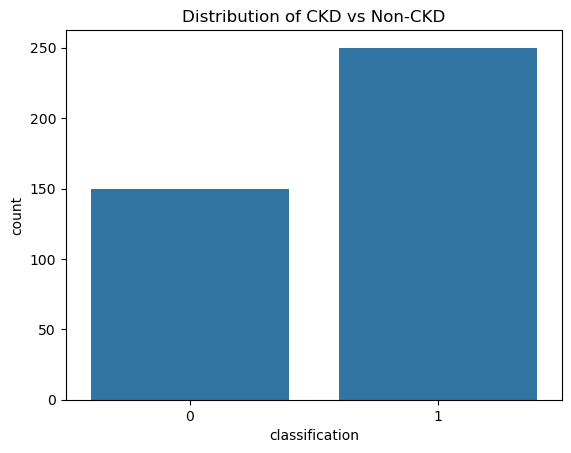

In [25]:
sns.countplot(x="classification",data=df)
plt.title("Distribution of CKD vs Non-CKD")
plt.show()

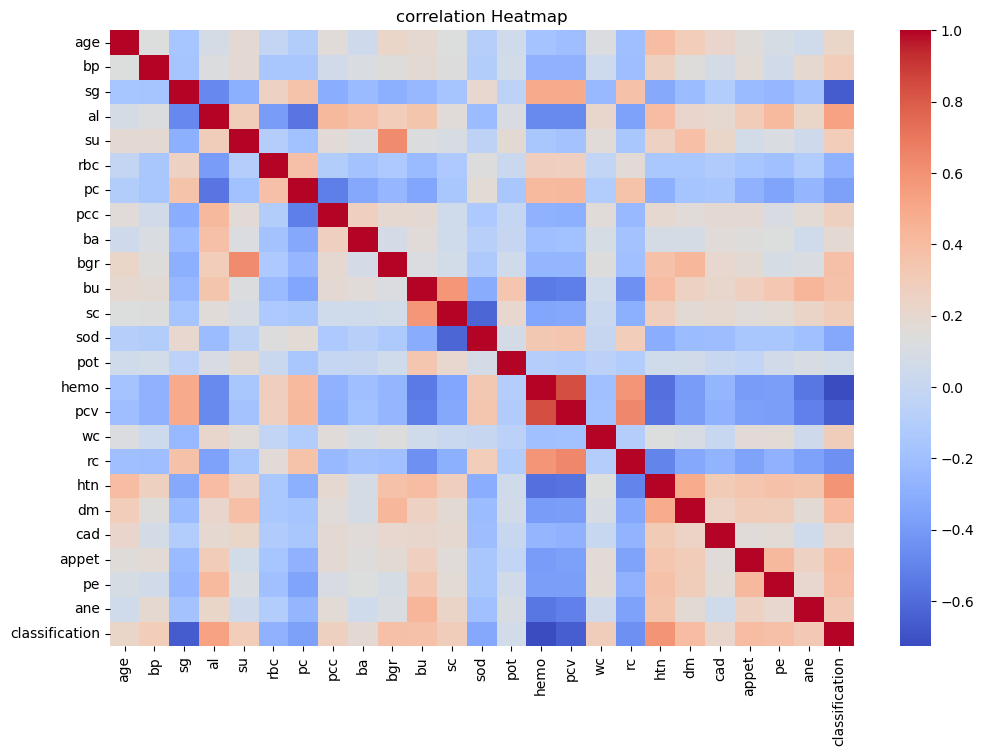

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.title("correlation Heatmap")
plt.show()

## Correlation Analysis Insights

The correlation heatmap shows strong relationships between certain medical parameters and CKD:

- Serum Creatinine shows strong positive correlation with CKD.
- Albumin level is positively correlated with CKD.
- Hemoglobin shows strong negative correlation with CKD.
- Packed Cell Volume also negatively correlates with CKD.

These findings align with medical knowledge that kidney dysfunction affects blood and protein levels.

<Axes: xlabel='classification', ylabel='hemo'>

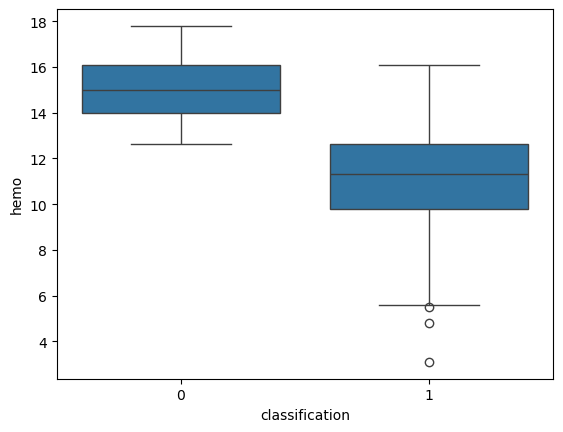

In [27]:
sns.boxplot(x="classification",y="hemo",data=df)

<Axes: xlabel='classification', ylabel='sc'>

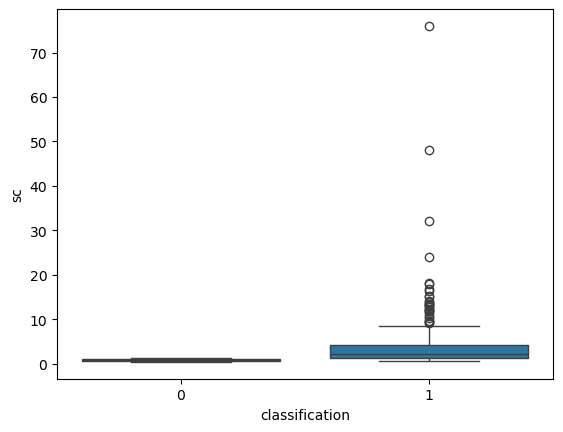

In [28]:
sns.boxplot(x="classification",y="sc",data=df)

## Hemoglobin and Serum Creatinine Analysis

The boxplots show clear differences between CKD and Non-CKD patients:

- CKD patients (class 1) have significantly lower hemoglobin levels compared to non-CKD patients.
- CKD patients exhibit higher serum creatinine levels.

These findings align with medical knowledge:

- Reduced hemoglobin indicates anemia >> which is common in chronic kidney disease due to reduced erythropoietin production.
- Elevated serum creatinine  >>  is a direct indicator of impaired kidney function.

Therefore, hemoglobin and serum creatinine are strong predictors for CKD classification.

In [29]:
X = df.drop("classification",axis=1)   # Features
y = df["classification"]               # Target

In [30]:
X

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,15.4,44.0,7800.0,5.2,1,4,1,0,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,11.3,38.0,6000.0,5.2,0,3,1,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,9.6,31.0,7500.0,5.2,0,4,1,1,0,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,11.2,32.0,6700.0,3.9,1,3,1,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,11.6,35.0,7300.0,4.6,0,3,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,1,1,0,0,140.0,...,15.7,47.0,6700.0,4.9,0,3,1,0,0,0
396,42.0,70.0,1.025,0.0,0.0,1,1,0,0,75.0,...,16.5,54.0,7800.0,6.2,0,3,1,0,0,0
397,12.0,80.0,1.020,0.0,0.0,1,1,0,0,100.0,...,15.8,49.0,6600.0,5.4,0,3,1,0,0,0
398,17.0,60.0,1.025,0.0,0.0,1,1,0,0,114.0,...,14.2,51.0,7200.0,5.9,0,3,1,0,0,0


In [31]:
y

0      1
1      1
2      1
3      1
4      1
      ..
395    0
396    0
397    0
398    0
399    0
Name: classification, Length: 400, dtype: int64

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)   ## 80:20 splited

In [33]:
X_train

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,11.2,32.0,6700.0,3.9,1,3,1,1,1,1
18,60.0,100.0,1.025,0.0,3.0,1,1,0,0,263.0,...,12.7,37.0,11400.0,4.3,1,4,2,0,0,0
202,78.0,60.0,1.020,0.0,0.0,1,1,0,0,114.0,...,8.0,24.0,9800.0,5.2,0,4,1,0,0,1
250,40.0,80.0,1.025,0.0,0.0,1,1,0,0,140.0,...,15.0,48.0,10400.0,4.5,0,3,1,0,0,0
274,19.0,80.0,1.020,0.0,0.0,1,1,0,0,107.0,...,14.4,44.0,9800.0,5.2,0,3,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,46.0,60.0,1.010,1.0,0.0,1,1,0,0,163.0,...,9.8,28.0,14600.0,3.2,1,4,1,0,0,0
106,50.0,90.0,1.020,0.0,0.0,1,1,0,0,89.0,...,6.0,17.0,6500.0,5.2,1,4,1,0,1,1
270,23.0,80.0,1.025,0.0,0.0,1,1,0,0,111.0,...,14.3,41.0,7200.0,5.0,0,3,1,0,0,0
348,38.0,80.0,1.020,0.0,0.0,1,1,0,0,99.0,...,13.6,44.0,7300.0,6.4,0,3,1,0,0,0


In [34]:
X_test

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
209,19.0,70.0,1.020,0.0,0.0,1,1,0,0,121.0,...,11.5,41.0,6900.0,5.2,0,3,1,0,0,0
280,47.0,80.0,1.020,0.0,0.0,1,1,0,0,93.0,...,13.3,52.0,8100.0,5.2,0,3,1,0,0,0
33,60.0,100.0,1.020,2.0,0.0,0,0,0,0,140.0,...,10.1,29.0,9800.0,5.2,1,3,1,1,0,0
210,59.0,100.0,1.015,4.0,2.0,1,1,0,0,255.0,...,7.3,20.0,9800.0,3.9,1,4,2,0,0,1
93,73.0,100.0,1.010,3.0,2.0,0,0,1,0,295.0,...,9.2,30.0,7000.0,3.2,1,4,2,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,48.0,110.0,1.015,3.0,0.0,0,1,1,0,106.0,...,8.6,26.0,5000.0,2.5,1,3,2,0,0,1
227,57.0,80.0,1.015,0.0,0.0,1,1,0,0,120.0,...,11.3,36.0,7200.0,3.8,1,4,1,0,0,0
369,75.0,70.0,1.020,0.0,0.0,1,1,0,0,107.0,...,13.6,46.0,10300.0,4.8,0,3,1,0,0,0
176,21.0,90.0,1.010,4.0,0.0,1,0,1,1,107.0,...,8.3,23.0,12400.0,3.9,0,3,1,0,0,1


In [35]:
lr = LogisticRegression(max_iter=1000)
lr

LogisticRegression(max_iter=1000)

In [36]:
lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [37]:
pred_lr = lr.predict(X_test)
from sklearn.metrics import accuracy_score
print("Logestic Regressionn Accuracy:",accuracy_score(y_test,pred_lr))

Logestic Regressionn Accuracy: 0.975


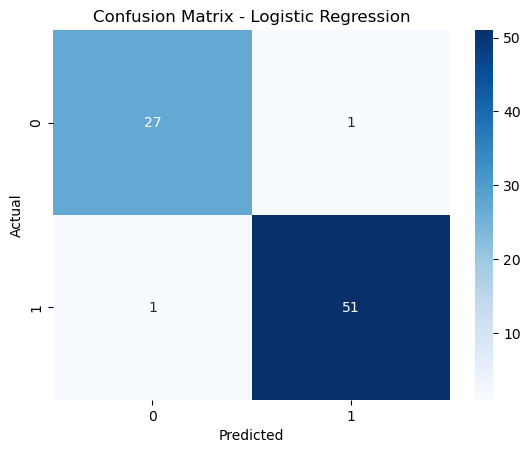

In [38]:
cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [39]:
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        28
           1       0.98      0.98      0.98        52

    accuracy                           0.97        80
   macro avg       0.97      0.97      0.97        80
weighted avg       0.97      0.97      0.97        80



## Logistic Regression Model Evaluation

The Logistic Regression model achieved 97.5% accuracy.

The confusion matrix shows only 2 misclassifications out of 80 test samples.

- Precision and recall values are high for both classes.
- Recall for CKD (class 1) is 0.98, meaning the model correctly identifies 98% of CKD patients.

In [40]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))
print(classification_report(y_test, pred_dt))

Decision Tree Accuracy: 0.9875
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        28
           1       1.00      0.98      0.99        52

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        52

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [42]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.9750
1,Decision Tree,0.9875
2,Random Forest,1.0000


## Model Comparison

- Logistic Regression: 97.5%
- Decision Tree: 98.75%
- Random Forest: 100%

Random Forest achieved the highest accuracy among all models.

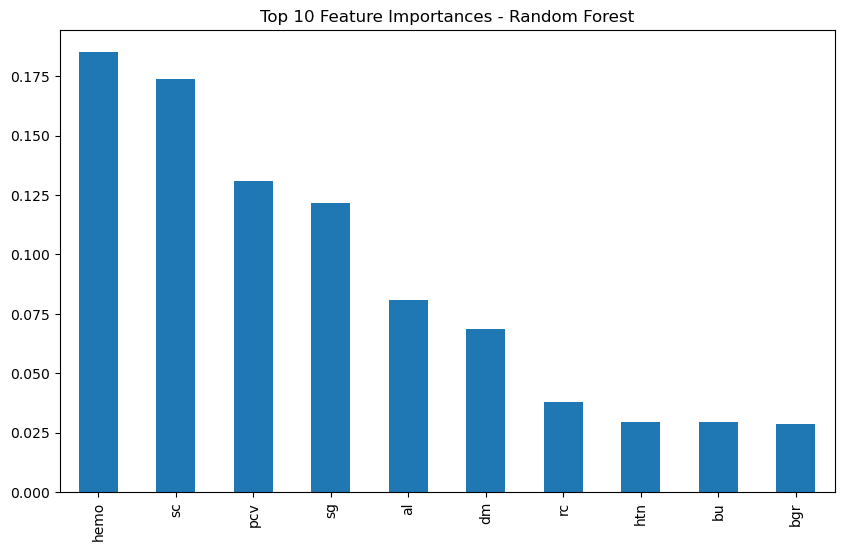

hemo    0.185181
sc      0.173978
pcv     0.130861
sg      0.121852
al      0.080779
dm      0.068803
rc      0.037944
htn     0.029603
bu      0.029379
bgr     0.028427
dtype: float64

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

importances = rf.feature_importances_
features = X.columns

feat_importance = pd.Series(importances, index=features)
feat_importance = feat_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_importance.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

feat_importance.head(10)

In [44]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.9875 1.     0.9875 0.9875 1.    ]
Average CV Score: 0.9925


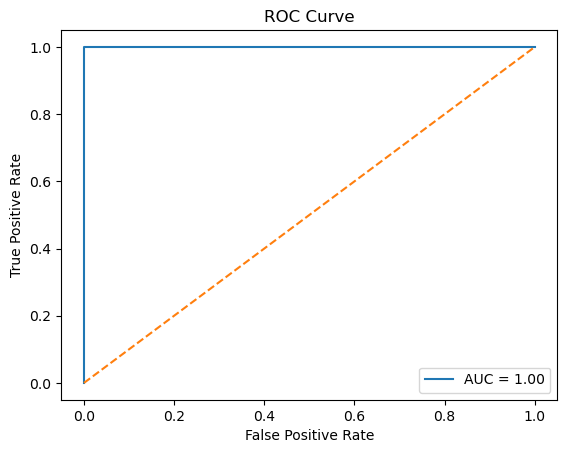

In [45]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Model Validation and Performance

The Random Forest model achieved:

- Test Accuracy: 100%
- Cross-Validation Accuracy: 99.25%
- ROC-AUC Score: ~1.0

The high and consistent cross-validation score confirms that the model is not overfitting.

The ROC curve demonstrates excellent class separation ability.

## Final insights
- Best performing model: Random Forest Classifier :
- Accuracy achieved: 100% on test data
- Cross-validation accuracy: ~98–99%, indicating strong generalization
- Most important features: Hemoglobin (hemo), Serum Creatinine (sc), Albumin (al), Packed Cell Volume (pcv), Hypertension (htn)
- The model demonstrates excellent predictive performance and shows strong reliability across different data splits.